# Principle Components Analysis (PCA)

## Loading and masking the dataset

In [126]:
from flowtorch.data import CSVDataloader, mask_box
import matplotlib.pyplot as plt
import torch
from scipy.signal import welch
import numpy as np

data = "../datasets/naca0012_buffet/surface/"
loader = CSVDataloader.from_foam_surface(data, "total(p)_coeff_airfoil.raw")

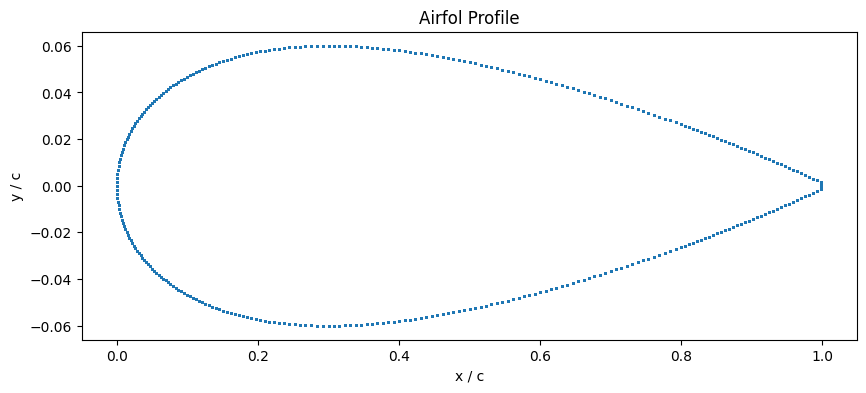

In [127]:
loader.vertices

chord_length = 0.60105 # m
norm_vertices = loader.vertices / chord_length

plt.figure(figsize=(10, 4))
plt.title("Airfol Profile")
plt.xlabel("x / c")
plt.ylabel("y / c")
plt.scatter(norm_vertices[:, 0], norm_vertices[:, 1], s=1)
plt.show()



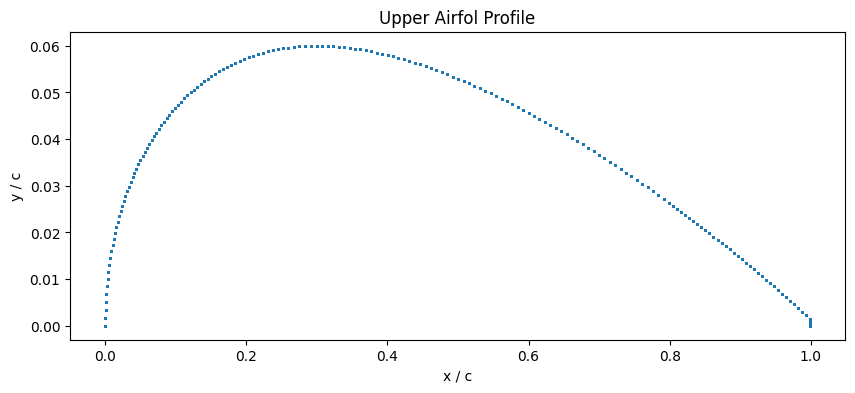

In [128]:
x_min , y_min, z_min = norm_vertices[:, 0].min(), 0, -1.0
x_max , y_max, z_max = norm_vertices[:, 0].max(), norm_vertices[:, 1].max(), 1.0

mask = mask_box(norm_vertices, lower=[x_min, y_min, z_min], upper=[x_max, y_max, z_max])

x = torch.masked_select(norm_vertices[:, 0], mask)
y = torch.masked_select(norm_vertices[:, 1], mask)
z = torch.masked_select(norm_vertices[:, 2], mask)

plt.figure(figsize=(10, 4))
plt.title("Upper Airfol Profile")
plt.xlabel("x / c")
plt.ylabel("y / c")
plt.scatter(x, y, s=1)
plt.show()

In [129]:
# First and last write times
print(f"First Write Time: {loader.write_times[0]} s")
print(f"Last Write Time: {loader.write_times[-1]} s")

# Compute Time Step
dt = float(loader.write_times[1]) - float(loader.write_times[0])
print(f"Time Step: {dt:.4f} s")

t_min = 0.03276 # s
t_max = 0.1015 # s

filtered_write_times = [t for t in loader.write_times if float(t) >= t_min and float(t) <= t_max] # t between t_min and t_max

# Create Data Matrix
num_points = mask.sum().item()
num_snapshots = len(filtered_write_times)
print(f"Number of Points with Mask: {num_points}")
print(f"Number of Snapshots between t_min and t_max: {num_snapshots}")
data_matrix = torch.zeros((num_points, num_snapshots)) # Matrix with 5018 Rows and 688 Cols

for (i, t) in enumerate(filtered_write_times):
  p_coeff = loader.load_snapshot("total(p)_coeff", t) # (10010, 1)
  p_coeff = torch.masked_select(p_coeff, mask) # (5018, 1)
  data_matrix[:, i] = p_coeff # Matrix with 5018 Rows with pres_coeff and 688 Cols with the snapshots

# Temporal Mean (Zeitlicher Mittelwert) variance on each Point
temporal_mean = data_matrix.mean(dim=1) # mean for each row -> (5018, 1)
var_cp = data_matrix.var(dim=1) # var for each row/point -> (5018, 1)

# Subtract Temporal Mean from Data Matrix
data_matrix = data_matrix - temporal_mean.unsqueeze(1)  # (5018, 688)


First Write Time: 0.03 s
Last Write Time: 0.1099 s
Time Step: 0.0001 s
Number of Points with Mask: 5018
Number of Snapshots between t_min and t_max: 688


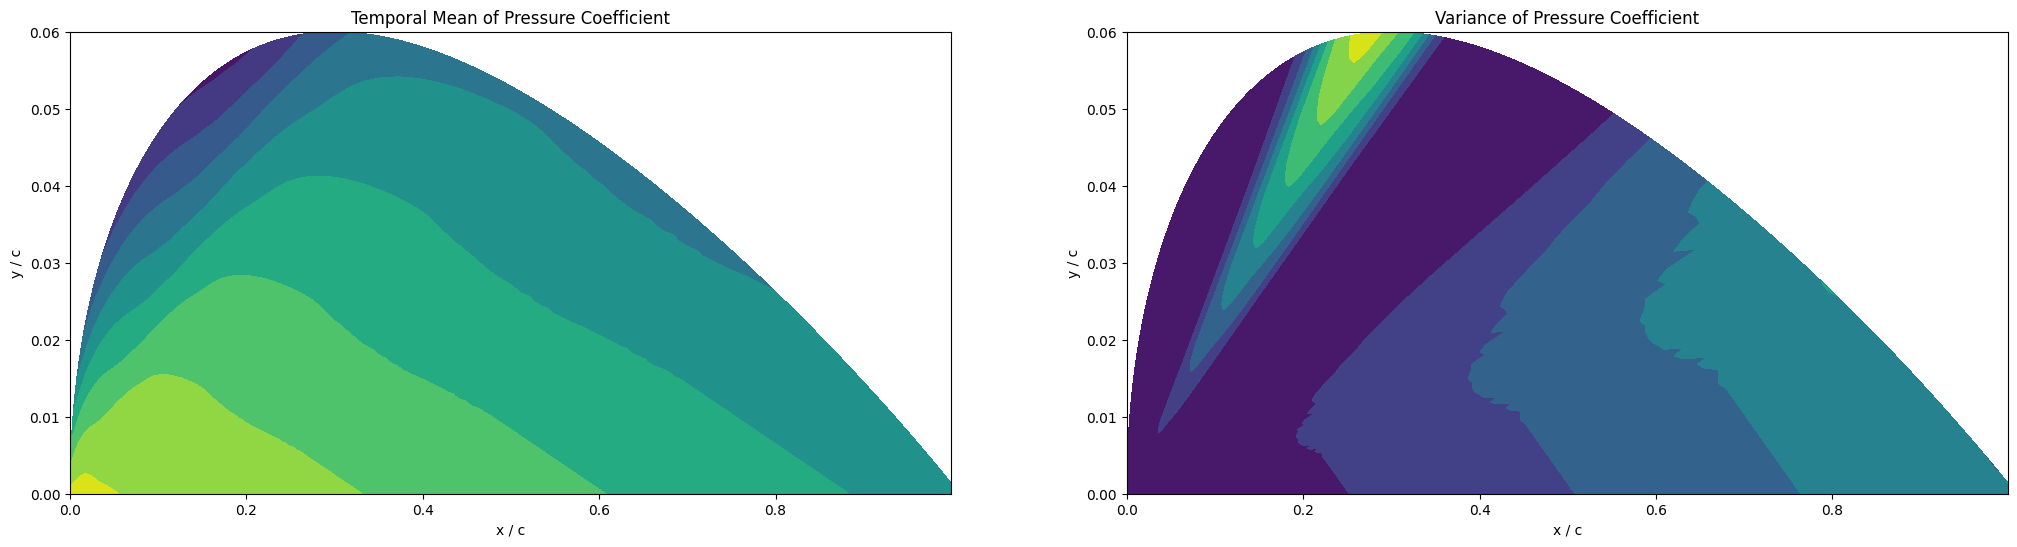

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(25,6))

axes[0].set_title("Temporal Mean of Pressure Coefficient")
axes[0].tricontourf(x, y, temporal_mean)
axes[0].set_xlabel("x / c")
axes[0].set_ylabel("y / c")

axes[1].set_title("Variance of Pressure Coefficient")
axes[1].tricontourf(x, y, var_cp)
axes[1].set_xlabel("x / c")
axes[1].set_ylabel("y / c")

plt.show()

## Computing the singular value decomposition

In [131]:
U, s, VH = torch.linalg.svd(data_matrix, full_matrices=False) # U, Sigma, V^T
V = VH.T

U.shape, s.shape, V. shape

(torch.Size([5018, 688]), torch.Size([688]), torch.Size([688, 688]))

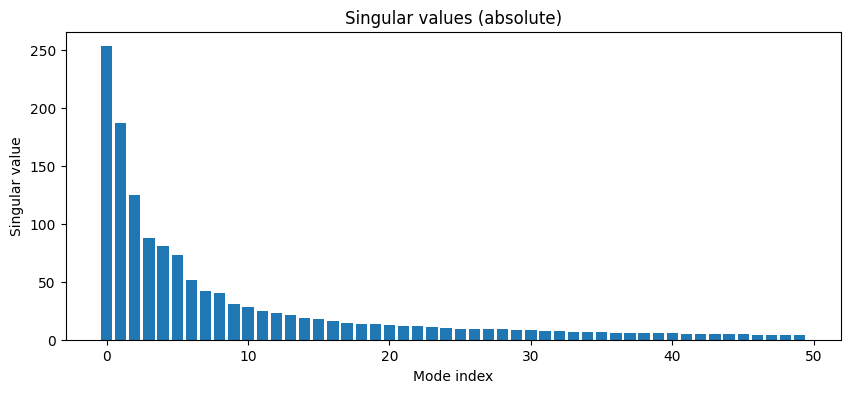

In [132]:
n_modes = 50
plt.figure(figsize=(10, 4))
plt.bar(range(n_modes), s[:n_modes])
plt.xlabel("Mode index")
plt.ylabel("Singular value")
plt.title("Singular values (absolute)")
plt.show()


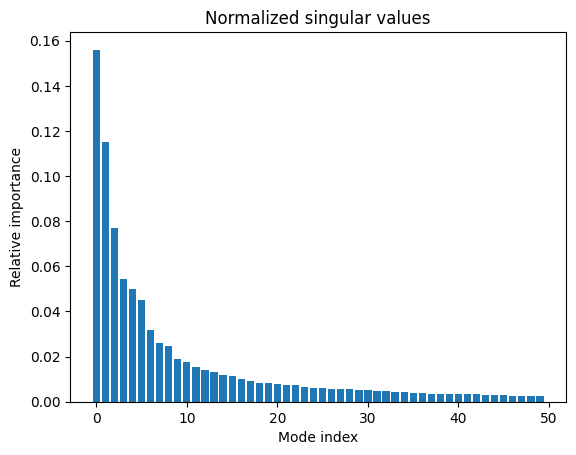

In [133]:
s_rel = s / s.sum()

plt.figure()
plt.bar(range(n_modes), s_rel[:n_modes])
plt.xlabel("Mode index")
plt.ylabel("Relative importance")
plt.title("Normalized singular values")
plt.show()


## Visualizing modes and mode coefficients

Maximum amplitude at f=36.3372Hz
Maximum amplitude at f=50.8721Hz
Maximum amplitude at f=130.8140Hz
Maximum amplitude at f=72.6744Hz
Maximum amplitude at f=65.4070Hz


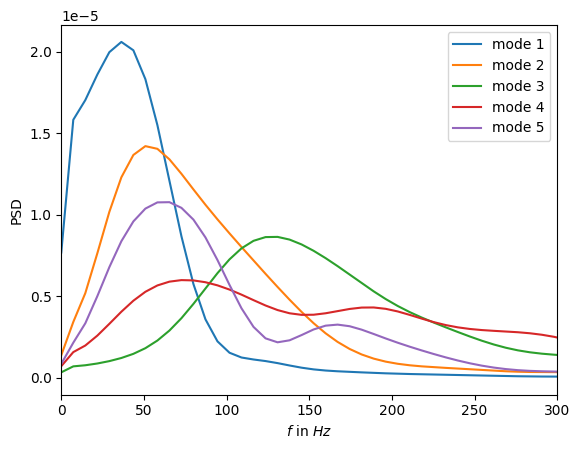

In [134]:
# times is a list containing the selected write times as floats
filtered_write_times = [float(t) for t in filtered_write_times]
dt = filtered_write_times[1] - filtered_write_times[0]
for i in range(5):
    f, power = welch(V[:, i], 1/dt, nfft=len(filtered_write_times)*2)
    plt.plot(f, power, label=f"mode {i+1}")
    print(f"Maximum amplitude at f={f[np.argmax(power)]:2.4f}Hz")

plt.legend()
plt.xlim(0, 300)
plt.xlabel(r"$f$ in $Hz$")
plt.ylabel("PSD")
plt.show()

Mode 1 represents the shock buffet.

# DMD implementation

- Wenn U eine Matrix ist, dann bezeichnet
$$
U^H = \bar{U}^{T}
$$


Aus der SVD gilt:

$$
X = U \Sigma V^H
$$

mit der Singulärwertmatrix

$$
\Sigma =
\begin{pmatrix}
\sigma_1 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_r
\end{pmatrix}
$$

Dabei gilt:

- $$\sigma_i > 0$$
- $$\Sigma \text{ ist diagonal, aber keine Einheitsmatrix}$$

---

## Inverse einer Diagonalmatrix

Für Diagonalmatrizen ist die Inversion besonders einfach:

$$
\Sigma^{-1} =
\begin{pmatrix}
\frac{1}{\sigma_1} & 0 & \cdots & 0 \\
0 & \frac{1}{\sigma_2} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \frac{1}{\sigma_r}
\end{pmatrix}
$$


In [151]:
# 0. Data matrices
data_matrix = data_matrix + temporal_mean.unsqueeze(1) # as the task says, datamatrix without temporal_mean so we add the substracted temporal mean
X = data_matrix[:, :-1] # (n, m-1) = (5018, 687) wittout last snapshot
Y = data_matrix[:, 1:] # (n, m-1) = (5018, 687) without first snapshot

# 1. SVD of data matrix
U, s, VH = torch.linalg.svd(X, full_matrices=False) # s ist Vektor mit allen singular values, aber mathematisch muss es es Matrix mit Diagonalen gleich den Singular Values
Sigma =  torch.diag(s)
V = VH.conj().T

print(U.shape, Sigma.shape, VH.shape) # (5018, 687), # (687, 687), (687, 687)

# 1.5 choose rank r
r = 687 # Experiment with it
U_r = U[:, :r]  # (n, r)
s_r = s[:r]     # (r, 1)
V_r = V[:, :r]  # (m-1, r)


# 2. Reduced linear operator
UH_r = U_r.conj().T # (687, 5018) komplex konjugiert
Sigma_r_inv = torch.diag(1 / s_r) # (r, r)

A_tilde = UH_r @ Y @ V_r @ Sigma_r_inv # (r, r)

print(A_tilde[0])

# 3. Eigen decomposition of reduced linear operator
eigenvals, W = torch.linalg.eig(A_tilde) # eigvals: (r,), W: (r, r)
Lambda = torch.diag(eigenvals) # (r, r)

# A_tilde = W @ Lambda @ torch.linalg.inv(W) exactly the same as the above but calculated with eigen decomposition

# 4. Reconstruct the eigenvectors (modes) of the full linear operator

Phi = (Y @ V_r @ Sigma_r_inv).type(torch.cfloat) @ W


torch.Size([5018, 687]) torch.Size([687, 687]) torch.Size([687, 687])
tensor([ 1.0000e+00, -4.3466e-03, -1.5360e-03, -7.9793e-03,  1.1787e-03,
        -6.0155e-04, -2.1100e-02, -5.2253e-03,  2.7110e-03, -1.2073e-02,
         8.7568e-03, -2.1787e-02, -8.3408e-03, -1.2330e-02,  3.7028e-03,
         1.1144e-02, -3.6132e-02, -6.9879e-03,  5.2116e-03,  1.4028e-03,
         1.1968e-02, -3.6785e-02, -1.0308e-02,  1.3166e-02,  3.2839e-02,
         9.8480e-03,  4.6374e-03, -7.7570e-03,  1.4604e-02,  4.7769e-03,
        -2.2004e-02, -3.5900e-02, -2.5150e-02, -5.1356e-02, -2.0946e-02,
         4.1473e-02, -4.3108e-02, -1.0238e-03, -4.3889e-03,  8.8717e-03,
         3.4007e-02, -5.1076e-02, -1.1565e-02, -4.4096e-02,  5.2526e-02,
         9.7758e-03,  6.4593e-02, -1.1548e-03, -2.7952e-02, -1.8314e-04,
         3.1147e-03, -8.1051e-03,  2.6626e-02,  3.3896e-02, -1.9180e-02,
         3.7956e-02, -2.8542e-03,  1.4360e-02, -4.1385e-02,  1.9942e-02,
         1.0504e-01,  1.0664e-03,  1.0109e-02,  2.5744

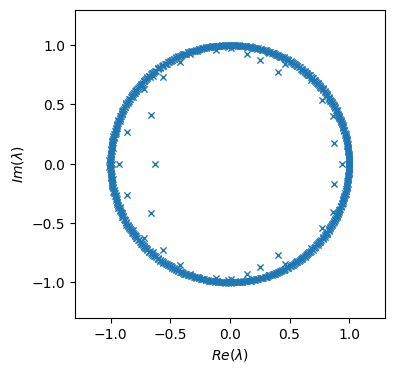

In [152]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
t = torch.linspace(0, 2 * np.pi, 100)
ax.plot(torch.cos(t), torch.sin(t), ls="--", color="k", lw=2)
ax.scatter(eigenvals.real, eigenvals.imag, marker="x", lw=1, s=20, zorder=7)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(r"$Re(\lambda)$")
ax.set_ylabel(r"$Im(\lambda)$")
plt.show()

## Plotting the spectrum

In [167]:
# 0. Parameters
dt = 0.001 # s
# 1. discrete -> continous
omega = torch.log(eigenvals) / dt

# 2. Frequency
freq = omega.imag / 2 * torch.pi
freq_i_pos = (freq > 0).nonzero().flatten()

# 3. Mode Amplitudes
x0 = X[:, 0].to(Phi.dtype)
b = torch.linalg.lstsq(Phi, x0).solution
b = b.real
amplitude = b.abs()

print("freq max:", freq[freq_i_pos].max().item())
print("Nyquist:", 1/(2*dt))


freq max: 4934.802734375
Nyquist: 500.0


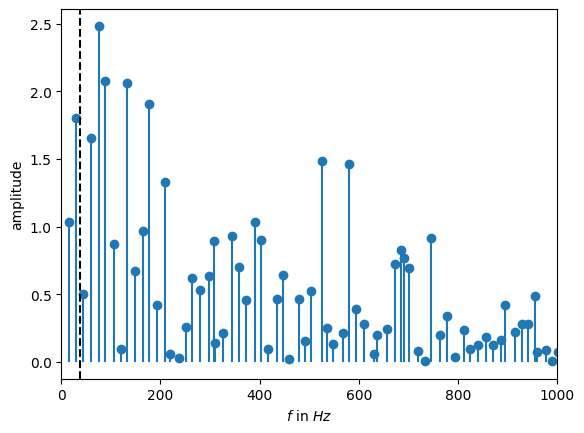

In [168]:
fig, ax = plt.subplots()

ax.stem(
    freq[freq_i_pos].cpu().numpy(),
    amplitude[freq_i_pos].cpu().numpy(),
    basefmt="none"
)

ax.set_xlim(0, 1000)     # ggf. anpassen
ax.axvline(38, ls="--", c="k")  # Referenzfrequenz aus Aufgabe
ax.set_xlabel(r"$f$ in $Hz$")
ax.set_ylabel("amplitude")

plt.show()
